# Dimensionality Reduction & Factor Extraction via PCA

**Objective:** Apply Principal Component Analysis (PCA) for dimensionality reduction and data visualization using two datasets: wine chemical constituents and breast cancer tumor imaging measurements.

<hr>

## Part 1: Italian Wine Dataset Analysis
This dataset is the results of a chemical analysis of wines grown in the same region in Italy derived from three different cultivars. The analysis determined the quantities of 13 constituents found in each of the 178 wine samples. Using this dataset, address the following questions:

### 1. Feature Correlation Analysis
Plot the correlation matrix between variables to examine inter-feature relationships. The heatmap allows us to visualize the pairwise correlation coefficients and preliminarily identify redundant features.

<Axes: >

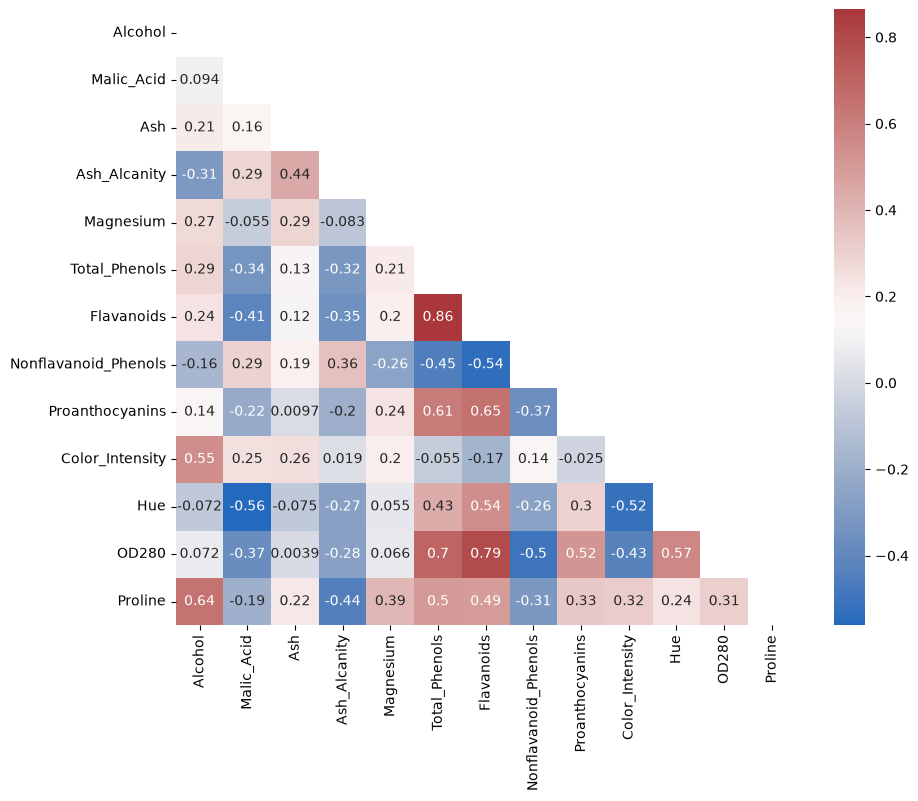

In [1]:
import numpy as np
import pandas as pd
import seaborn 
import matplotlib.pyplot as plt

df = pd.read_excel('wine.xlsx').drop(["Customer_Segment"],axis = 1) # use the drop() method to remove the Customer_Segment column
ratings = np.array(df)
categories = df.columns
R = df.corr()
mask = np.triu(np.ones_like(R, dtype = bool))
plt.figure(figsize = (10,8)) # increased the figure size to prevent overlapping
seaborn.heatmap(R, annot = True, mask = mask, cmap = 'vlag')

#### Discussion:
* The heatmap indicates that variables closer to red exhibit strong positive correlation (approaching 1), while those closer to blue show strong negative correlation (approaching -1). For instance, `Flavanoids` and `Total_Phenols` demonstrate a high positive correlation with a coefficient of 0.86, whereas `Hue` and `Malic_Acid` show a notable negative correlation with a coefficient of -0.56.

* These strong pairwise correlations and potential multicollinearity among the 13 chemical constituents justify the necessity of applying PCA to extract orthogonal components and reduce dimensionality.

### 2. Feature Scaling & Distribution Analysis

Plot a boxplot for each chemical constituent (variable) to examine their respective scales and variances, serving as a reference for whether data standardization is required prior to PCA.

#### 2.1 Unstandardized Data:

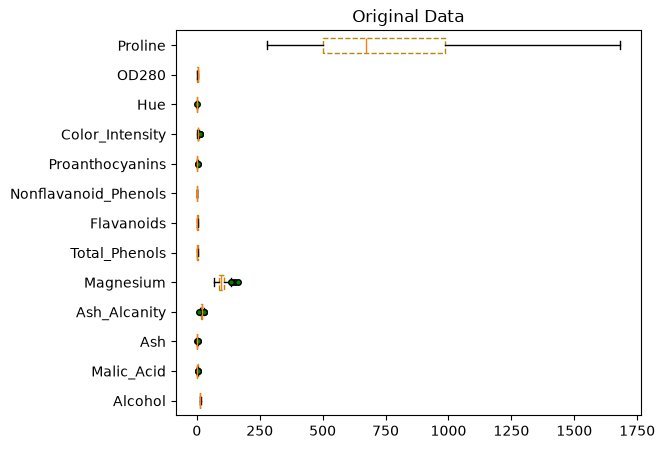

In [2]:
import matplotlib.pyplot as plt
import seaborn

# ratings, categories are carried over from 1.
# unstandardized
fig, ax = plt.subplots(figsize = (6,5))
boxprops = dict(linestyle = '--',linewidth = 1,color = 'darkgoldenrod') #E59016
flierprops = dict(marker='o', markerfacecolor = 'green', markersize = 4, linestyle = 'none')
ax.boxplot(ratings, tick_labels = categories, boxprops = boxprops, flierprops = flierprops, orientation='horizontal')
plt.title('Original Data')
plt.show()

#### Discussion:
The boxplot reveals significant scale discrepancies among the features. Specifically, **Proline** exhibits a notably larger numerical range (extending up to nearly 1750), whereas other variables are compressed near the lower end. This vast variance disparity indicates that unstandardized features would disproportionately bias the PCA results. Therefore, **feature standardization** is essential prior to PCA to ensure all variables contribute equally to the principal components.

#### 2.2 Standardized Data:

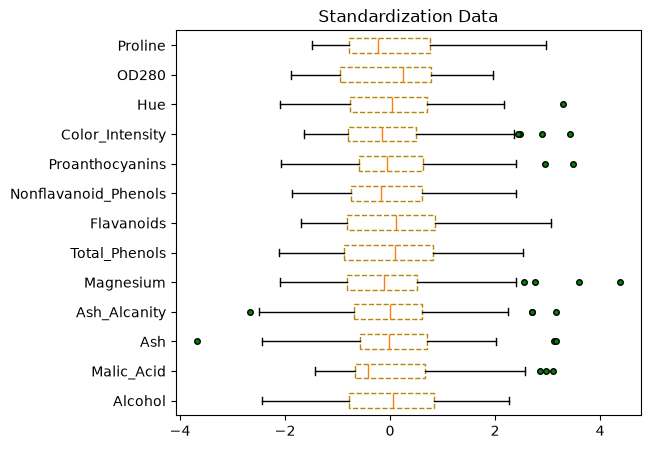

In [3]:
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler

#standardized
scaler = StandardScaler()
scaler.fit(ratings)
ratings_ = scaler.transform(ratings)

fig, ax = plt.subplots(figsize = (6,5))
boxprops = dict(linestyle = '--',linewidth = 1,color = 'darkgoldenrod') #E59016
flierprops = dict(marker='o', markerfacecolor = 'green', markersize = 4, linestyle = 'none')
ax.boxplot(ratings_, tick_labels = categories, boxprops = boxprops, flierprops = flierprops, orientation='horizontal')
plt.title('Standardization Data')
plt.xticks(np.arange(-4,6,2))
plt.show()

#### Discussion:

* **Scale Harmonization**: Following standardization (mean = 0, variance = 1), all 13 chemical constituents are now on a comparable scale. This eliminates the disproportionate dominance of high-magnitude features (such as `Proline`) and ensures that each feature contributes equally to the subsequent variance-based PCA.

* **Distribution & Outlier Analysis**: Post-scaling boxplots reveal that features like `Magnesium`, `Ash_Alcanity`, and `Hue` retain noticeable outliers (green markers) beyond the standard whiskers. These distributions demonstrate that while scaling normalizes the feature variance, non-normal skewness and outliers in specific constituents still warrant careful dimensionality reduction.

### 3. Scree Plot Showing the Magnitude of Eigenvalues
Perform principal component analysis, plot the distribution of eigenvalues from largest to smallest along with the scree plot, and refer to the layout in Figure 2.

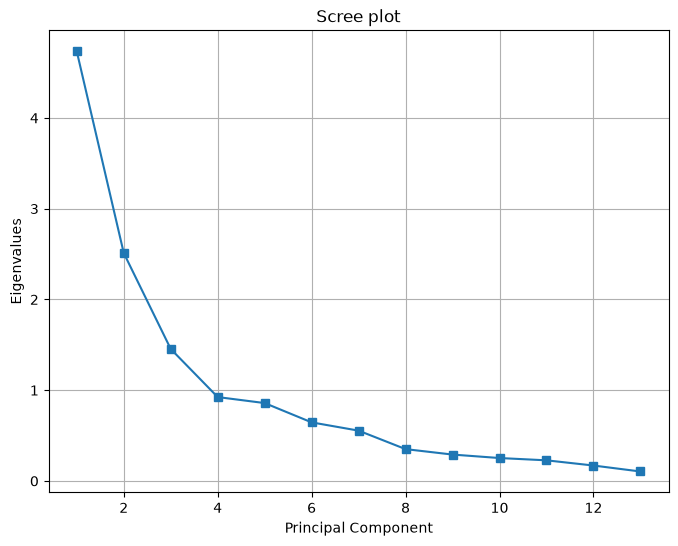

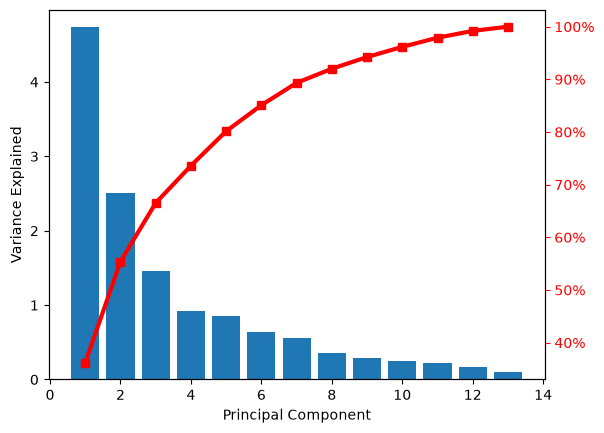

In [4]:
import numpy as np
from numpy.linalg import eig
from matplotlib.ticker import PercentFormatter
from matplotlib.pyplot import MultipleLocator

Sx = np.cov(ratings_.T, bias = False) # standardized data # row as variables, column as observation of varaibles # unbias : n-1
w, v = eig(Sx)
index = np.argsort(w)[::-1]
eigvals = w[index].real
eigvecs = v[:,index].real
Sigma_x = eigvecs @ np.diag(eigvals) @ eigvecs.T

plt.figure(figsize = (8,6)) # initialize an empty figure
x = np.arange(1, 1+len(eigvals))
plt.plot(x, eigvals, marker='s')
plt.title('Scree plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalues')
plt.grid(True)
plt.show()

fig, ax = plt.subplots() # initialize an empty figure and axis
x = np.arange(1, 1+len(eigvals))
ax.bar(x, eigvals)
ax2 = ax.twinx() # add axes
ax2.plot(x, eigvals.cumsum()/eigvals.sum()*100, \
marker='s', color='red', lw=3) #.cumsum: cumulative sum of array
ax2.tick_params(axis='y', colors='red') # customize the tick styles # ticks_params(axis='x or y', width, color....)
ax2.yaxis.set_major_formatter(PercentFormatter()) # adjust y-axis ticks or formatting
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
plt.show()

#### Discussion:
* **Principal Component Analysis (PCA)** reduces data complexity while preserving information, aiming to represent the maximum components (variables) of the original data using the fewest variables. The new variables are linear combinations of the original variables, retaining the maximum variance among them.

* **The scree plot** displays eigenvalues as a downward-sloping curve, where an "elbow" point is often visually identified to suggest a suitable number of principal components. As an alternative approach, the **Kaiser criterion** recommends retaining principal components with eigenvalues greater than 1.

* The presence of a zero eigenvalue indicates that the data matrix is not full rank, implying complete linear dependency among variables (i.e., some variables are completely redundant). In the actual distribution of this dataset, the eigenvalues decrease gradually and most are greater than 0, reflecting actual correlation and overlapping information among the original variables. Because of this correlation, the variance is highly concentrated in the first few principal components, enabling us to effectively represent the original 13-dimensional data with a few larger eigenvalues.

* If there are too many principal components (greater than three), PCA is no longer the optimal choice for data visualization.

* **Since there are 3 principal components with an eigenvalue > 1, it can be concluded that the first 3 principal components are sufficient to represent most of the variance in the original data.**

### 4. The Impact of Standardization on PCA and Cluster Visualization

Without considering the data labels, when plotting a scatter plot using the first two principal components, **whether the data is standardized beforehand** has a critical impact on the analysis results:

#### 4.1 Unstandardized Data:

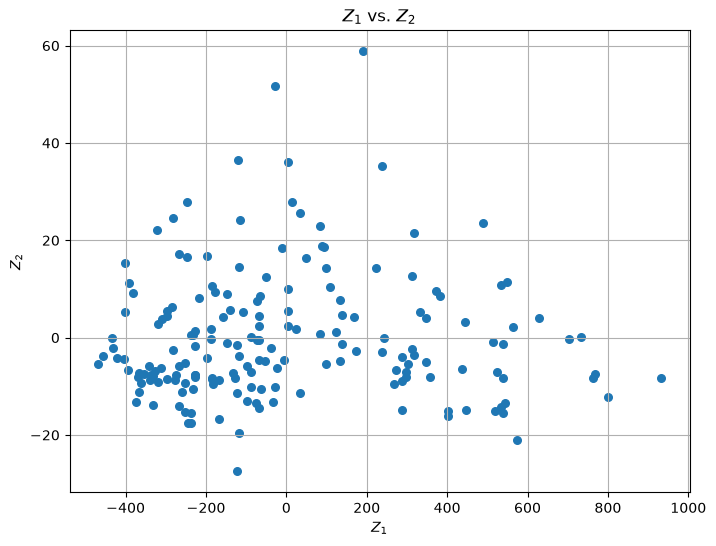

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# unstandardized
pca = PCA(n_components=2)
pca_ = pca.fit_transform(ratings)

plt.figure(figsize = (8,6))
plt.scatter(pca_[:,0], pca_[:,1],s = 30)
plt.title("$Z_1$ vs. $Z_2$")
plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')
plt.grid(True)
plt.show()

#### Discussion:
The groups are not clearly distinguishable in the scatter plot, and the data points are dispersed and blended together.

#### 4.2 Standardized Data:

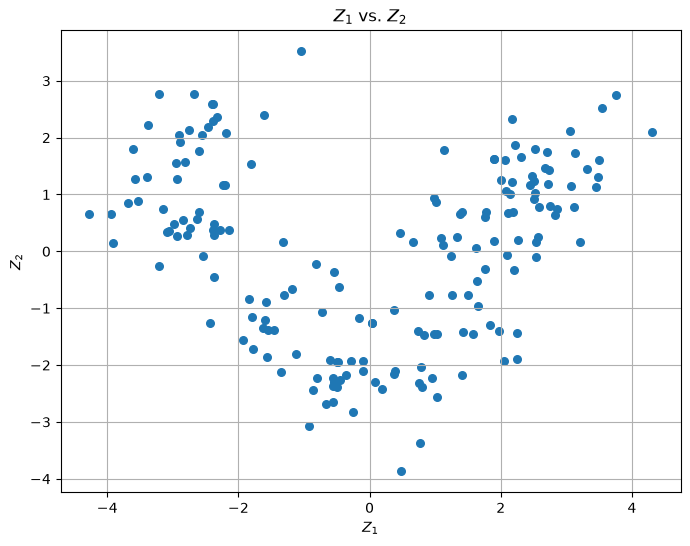

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# standardized
pca = PCA(n_components=2)
pca_ = pca.fit_transform(ratings_)

plt.figure(figsize = (8,6))
plt.scatter(pca_[:,0], pca_[:,1],s = 30)
plt.title("$Z_1$ vs. $Z_2$")
plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')
plt.grid(True)
plt.show()

#### Discussion:
**Clear Cluster Separation**: Without looking at the labels, it can be found that the plot is divided into three distinct regions (lower-left, upper-middle, and lower-right), showing a significant difference compared to the unstandardized results.

### 5. PCA Scatter Plot Colored by True Wine Classes
Color each data point in the scatter plot based on its respective label.

#### 5.1 Unstandardized Data:

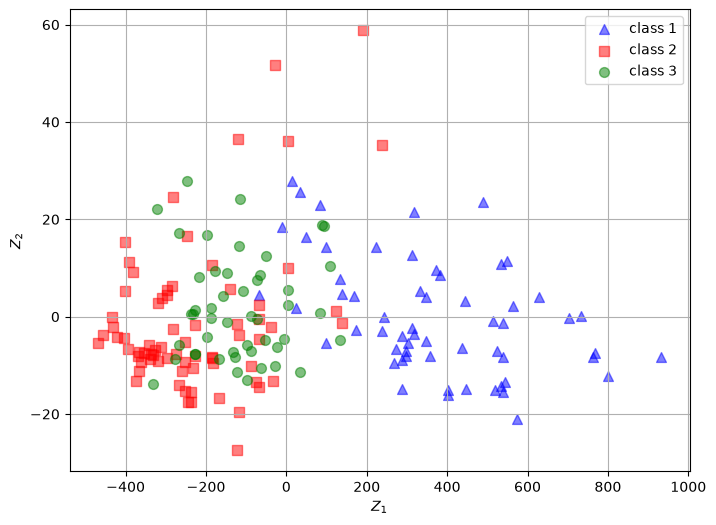

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DF = pd.read_excel('wine.xlsx')
scaler = StandardScaler()
scaler.fit(ratings)
ratings_ = scaler.transform(ratings)
pca = PCA(n_components=2)
pca_ = pca.fit_transform(ratings)

wine_labels = DF.iloc[:,13]
targets = range(1, 4)
labels = ['class 1','class 2','class 3']
colors = ['blue','red','green']
markers = ['^','s','o']

plt.figure(figsize = (8,6))
for target, color, marker in zip(targets,colors,markers):
    plt.scatter(pca_[wine_labels == target,0], pca_[wine_labels == target,1], label = f"class {target}",color = color, alpha = 0.5, marker = marker, s = 50)
plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')
plt.grid(True)
plt.legend(labels,loc="upper right")
plt.show()

#### 5.2 Standardized Data:

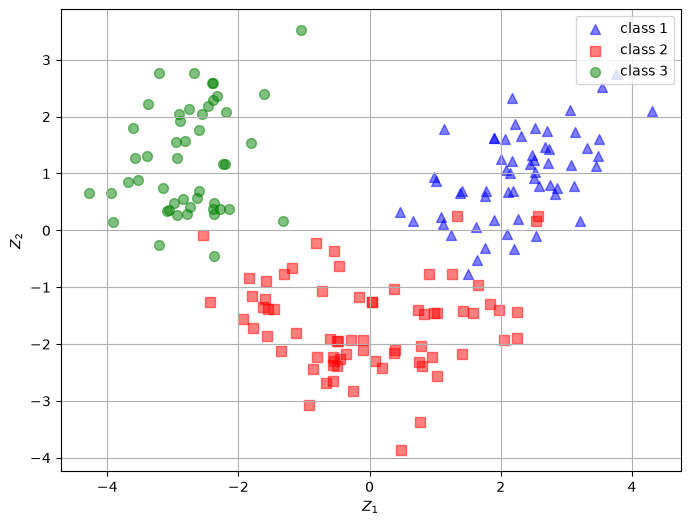

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DF = pd.read_excel('wine.xlsx')
scaler = StandardScaler()
scaler.fit(ratings)
ratings_ = scaler.transform(ratings)
pca = PCA(n_components=2)
pca_ = pca.fit_transform(ratings_)

wine_labels = DF.iloc[:,13]
targets = range(1, 4)
labels = ['class 1','class 2','class 3']
colors = ['blue','red','green']
markers = ['^','s','o']

plt.figure(figsize = (8,6))
for target, color, marker in zip(targets,colors,markers):
    plt.scatter(pca_[wine_labels == target,0], pca_[wine_labels == target,1], label = f"class {target}",color = color, alpha = 0.5, marker = marker, s = 50)
plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')
plt.grid(True)
plt.legend(labels,loc="upper right")
plt.show()

#### Discussion:
* **Clear Class Separation**: After coloring the data points based on their true labels, it is evident that the data forms three distinct clusters (Class 1, Class 2, and Class 3) with minimal overlap.

* **Significance of Standardization**: This highlights the necessity of data standardization: unstandardized data yields a dispersed and mixed distribution after PCA, whereas standardized data successfully reveals the underlying three-class structure.

### 6. Three-Dimensional Principal Component Analysis
If three principal components are used, 3D scatter plots as shown in Figure 3 and Figure 4 can be generated. Observe whether Figures 3 and 4 provide better cluster separation capability compared to Figure 2. Try rotating the 3D plot's perspective to achieve the best viewing angle for discrimination.

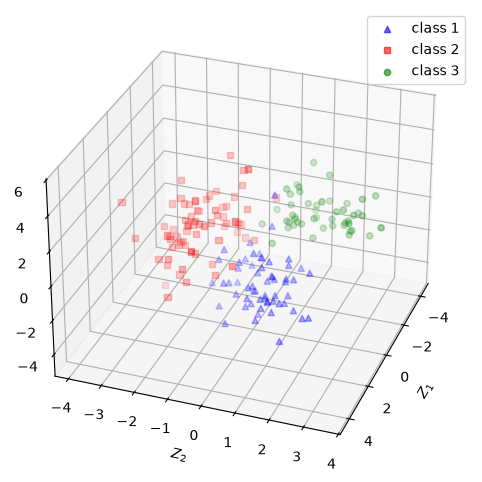

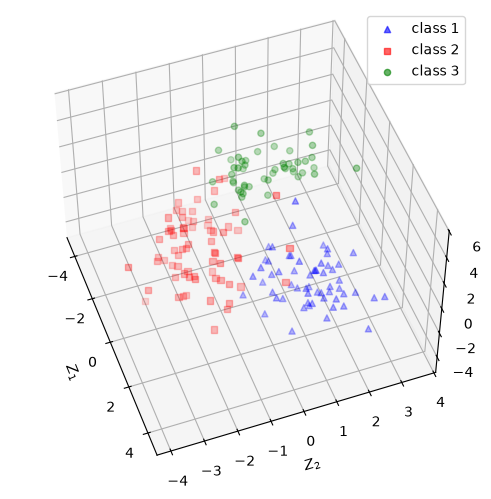

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d.axes3d import Axes3D

DF = pd.read_excel('wine.xlsx')
scaler = StandardScaler()
scaler.fit(ratings)
ratings_ = scaler.transform(ratings)
pca = PCA(n_components=3)
pca_ = pca.fit_transform(ratings_)

wine_labels = DF.iloc[:,13]
targets = range(1, 4)
labels = ['class 1','class 2','class 3']
colors = ['blue','red','green']
markers = ['^','s','o']

# angle 1
fig = plt.figure(figsize = (8,6))
ax1 = fig.add_subplot(projection='3d')
for target, color, marker in zip(targets,colors,markers):
    ax1.scatter(pca_[wine_labels == target,0], pca_[wine_labels == target,1],pca_[wine_labels == target,2], label = f"class {target}",color = color, alpha = 0.6,marker = marker)
ax1.view_init(30, 20)
plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')
plt.grid(True)
plt.legend(labels,loc="upper right")
plt.show()

# angle 2
fig = plt.figure(figsize = (8,6))
ax2 = fig.add_subplot(projection='3d')
for target, color, marker in zip(targets,colors,markers):
    ax2.scatter(pca_[wine_labels == target,0], pca_[wine_labels == target,1],pca_[wine_labels == target,2], label = f"class {target}",color = color, alpha = 0.6,marker = marker)
ax2.view_init(50, -20)
plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')
plt.grid(True)
plt.legend(labels,loc="upper right")
plt.show()

#### Discussion:
* The viewing angles of the 3D plot consist of two components: **elevation** and **azimuth**. By adjusting these angles, the data points are clearly separated into three distinct groups with minimal overlap.

* Based on the scree plot and Kaiser's criterion (Eigenvalue > 1), the first three principal components capture the majority of the variance, confirming that 3D visualization effectively highlights the cluster structure of the wine dataset.

### 7. 
$Z_1$ and $Z_2$ are new variables formed by combining the original variables. Can we determine which original variables are more important and which are less important from the loading coefficients of $Z_1$ and $Z_2$?

In [10]:
from numpy.linalg import eigh

Sx_numpy = np.cov(ratings_.T,bias = False)
w, v = eigh(Sx_numpy) #first is eigenvalue, second is eigenvectors
idx = np.argsort(w)[::-1] # argsort sorts the elements in ascending order and returns their corresponding indices.
eigvals = w[idx]
eigvecs = v[:, idx] # vector [row,column]----> v[:,idx] all row, idx column 
Sigma_x = eigvecs @ np.diag(eigvals) @ eigvecs.T

print(eigvecs)

[[-0.1443294   0.48365155  0.20738262 -0.0178563  -0.26566365 -0.21353865
   0.05639636 -0.39613926  0.50861912  0.21160473  0.22591696  0.26628645
   0.01496997]
 [ 0.24518758  0.22493093 -0.08901289  0.53689028  0.03521363 -0.53681385
  -0.42052391 -0.06582674 -0.07528304 -0.30907994 -0.07648554 -0.12169604
   0.02596375]
 [ 0.00205106  0.31606881 -0.6262239  -0.21417556 -0.14302547 -0.15447466
   0.14917061  0.17026002 -0.30769445 -0.02712539  0.49869142  0.04962237
  -0.14121803]
 [ 0.23932041 -0.0105905  -0.61208035  0.06085941  0.06610294  0.10082451
   0.28696914 -0.42797018  0.20044931  0.05279942 -0.47931378  0.05574287
   0.09168285]
 [-0.14199204  0.299634   -0.13075693 -0.35179658  0.72704851 -0.03814394
  -0.3228833   0.15636143  0.27140257  0.06787022 -0.07128891 -0.06222011
   0.05677422]
 [-0.39466085  0.06503951 -0.14617896  0.19806835 -0.14931841  0.0841223
   0.02792498  0.40593409  0.28603452 -0.32013135 -0.30434119  0.30388245
  -0.46390791]
 [-0.4229343  -0.003359

In [11]:
# the first two eigenvectors of the covariance matrix
z = pca.components_[:2,:]
print(z)

[[ 0.1443294  -0.24518758 -0.00205106 -0.23932041  0.14199204  0.39466085
   0.4229343  -0.2985331   0.31342949 -0.0886167   0.29671456  0.37616741
   0.28675223]
 [ 0.48365155  0.22493093  0.31606881 -0.0105905   0.299634    0.06503951
  -0.00335981  0.02877949  0.03930172  0.52999567 -0.27923515 -0.16449619
   0.36490283]]


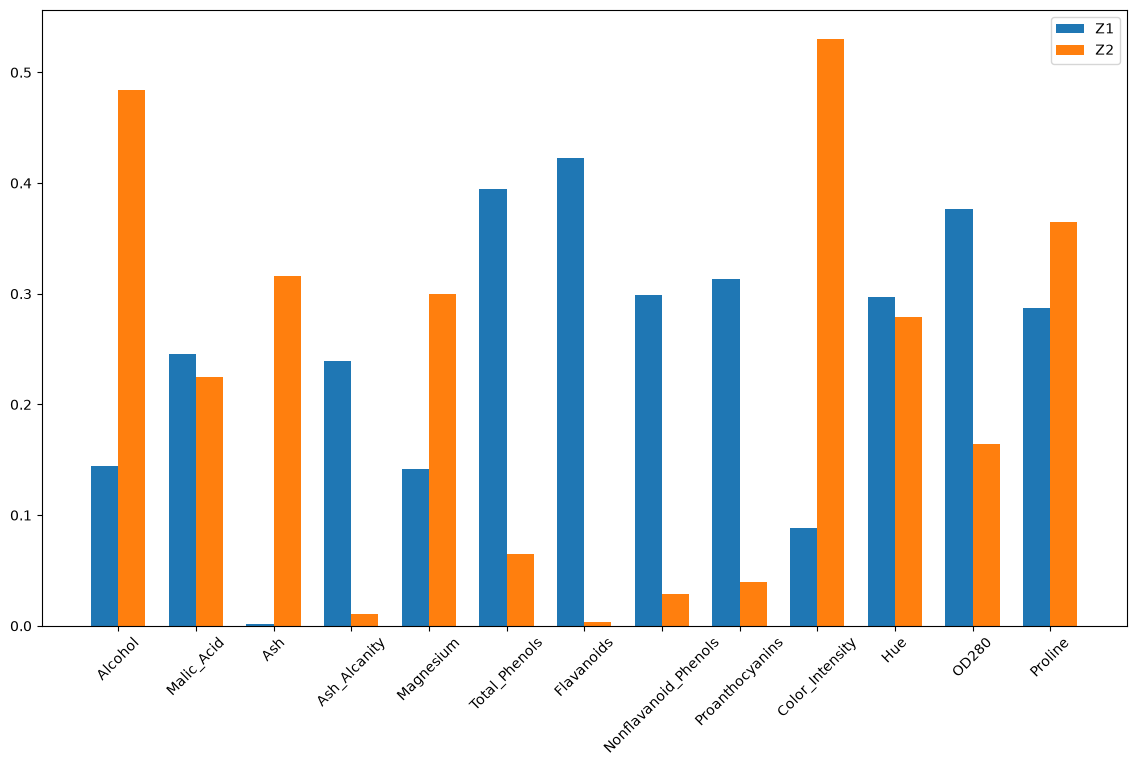

In [12]:
bar_width = 0.35
z = np.abs(pca.components_[:2,:])
x = np.arange(z.shape[1])
categories = df.columns

fig, ax = plt.subplots(figsize = (14,8))
ax.bar(x, z[0,:], width=bar_width,label = "Z1")
ax.bar(x + bar_width, z[1,:], width=bar_width,label = "Z2")
ax.set_xticks(x+bar_width/2)
ax.set_xticklabels(categories,rotation = 45)
plt.legend()
plt.show()

#### Discussion:
* **$Z_1$** is primarily composed of `Total_Phenols`, `Flavanoids`, `OD280`, `Proanthocyanins`, and `Nonflavanoid_Phenols`.

* **$Z_2$** is primarily composed of `Alcohol`, `Color_Intensity`, `Proline`, `Ash`, and `Magnesium`.

### 8.
Compared with the correlation coefficient plot of the original variables, does it reveal the same information?

<Axes: >

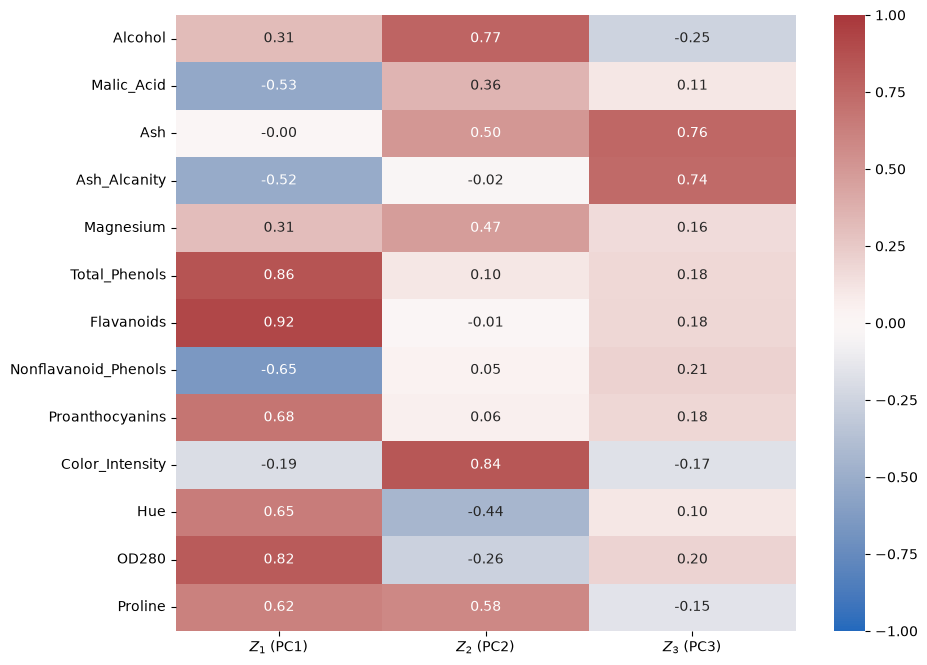

In [13]:
# the loadings heatmap
pca = PCA(n_components=3)
pca.fit(ratings_)
z = (pca.components_.T * np.sqrt(pca.explained_variance_))[:, :3]

L = pd.DataFrame(z,index = categories, columns = ['$Z_1$ (PC1)', '$Z_2$ (PC2)', '$Z_3$ (PC3)'])
R = df.corr()

plt.figure(figsize = (10,8))
seaborn.heatmap(L, annot = True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1,
            center=0)

#### Discussion:

The loadings heatmap reveals that:
* `Flavanoids` (0.92), `Total_Phenols` (0.86) and `OD280` (0.82) exhibit extremely high positive loadings on the first principal component ($Z_1$ (PC1)). 
* `Color_Intensity` (0.84) and `Alcohol` (0.77) exhibit extremely high positive loadings on the second principal component ($Z_2$ (PC2)). 
* `Ash` (0.76) and `Ash_Alcanity` (0.74) exhibit extremely high positive loadings on the third principal component ($Z_3$ (PC3)).

This indicates that they are the primary core components shaping $Z_1$ (PC1), $Z_2$ (PC2), and $Z_3$ (PC3), respectively, each capturing distinct dimensions of the dataset's overall variance.

#### Conclusion:

* **For $Z_1$**: `Flavanoids`, `Total_Phenols`, and `OD280` show relatively high positive loadings on PC1, with `Flavanoids` (0.92) and `Total_Phenols` (0.86) having the strongest contributions. This suggests that these variables are important in explaining the variation represented by PC1. The original feature correlation matrix also shows a strong positive correlation between `Flavanoids` and `Total_Phenols` (r = 0.86), supporting their close relationship.

* **For $Z_2$**: `Color_Intensity` and `Alcohol` have the highest positive loadings on PC2, with loading values of 0.84 and 0.77, respectively. Therefore, these variables contribute strongly to the variation represented by PC2. The original feature correlation matrix also shows a strong positive correlation between `Color_Intensity` and `Alcohol` (r = 0.55).

* **For $Z_3$**: `Ash` and `Ash_Alcanity` have the highest positive loadings on PC3, with values of 0.76 and 0.74, respectively. This indicates that these two variables contribute strongly to PC3. In the original feature correlation matrix, `Ash` and `Ash_Alcanity` also show a positive correlation (r = 0.44).

* **Comparison with the Correlation Matrix**: The loadings and the original correlation matrix reveal similar patterns but provide different information. The correlation matrix shows strong relationships among groups of original variables. For example, `Flavanoids` and `Total_Phenols` are strongly positively correlated (r = 0.86), and both have relatively large positive loadings in PC1. Similarly, `Color_Intensity` and `Alcohol` show a positive correlation (r = 0.55), and both have relatively large positive loadings in PC2. For PC3, `Ash` and `Ash_Alcanity` have relatively large positive loadings, while their correlation is moderately positive (r = 0.44).
However, the correlation matrix describes the relationships between pairs of original variables, whereas the loadings describe the contribution and direction of each variable to a principal component.

* **Overall**:
Therefore, the correlation matrix can help explain why certain variables tend to vary together and may contribute similarly to a principal component. However, the absolute values of the loadings are more directly useful for determining which variables contribute most strongly to PC1, PC2, and PC3.

<hr>

## Part 2: Breast Cancer Patient Tumors Dataset Analysis
Repeating the above problem with the wine dataset, the data is a set of image measurement data regarding breast cancer patient tumors from `sklearn.datasets`. There are 30 measured variables and 569 patients, divided into two groups: Malignant and Benign. Due to the large number of variables, the correlation plot must be modified compared to the previous exercise.

### 1. Feature Correlation Analysis
Plot the correlation matrix between variables to examine inter-feature relationships. The heatmap allows us to visualize the pairwise correlation coefficients and preliminarily identify redundant features.

<Axes: >

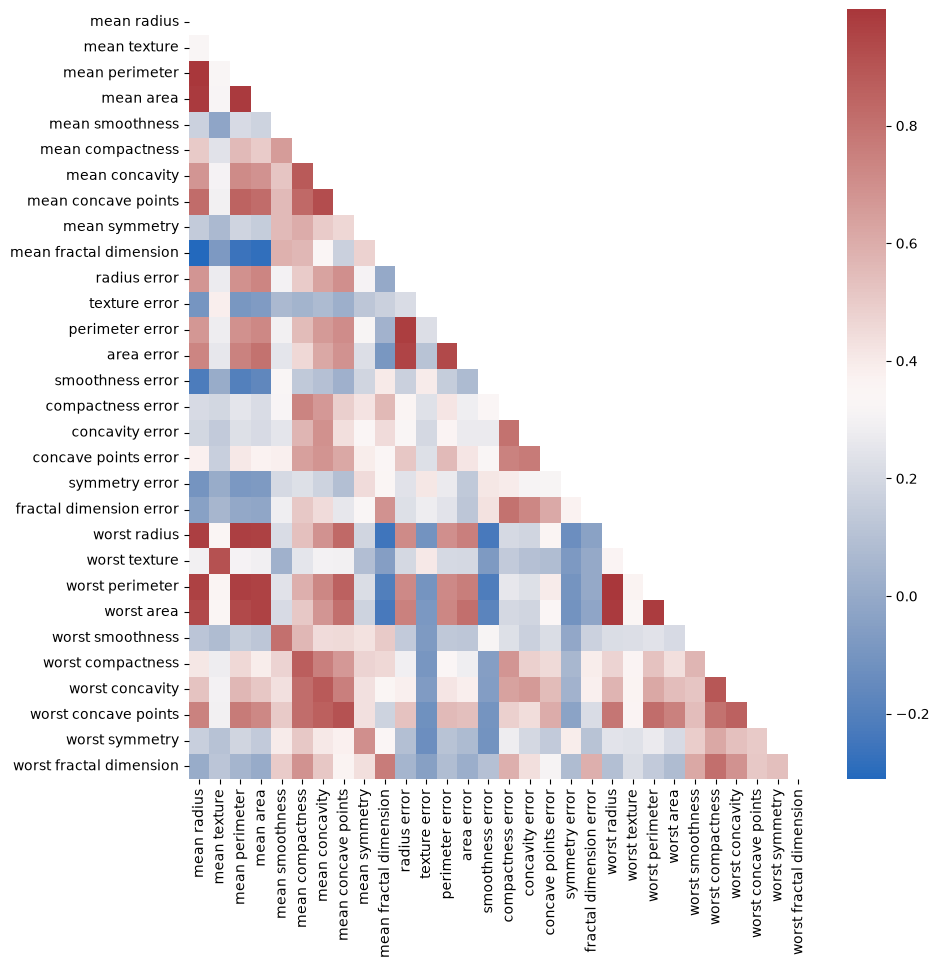

In [14]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = load_breast_cancer()
data = df.data #569x30
categories = df.feature_names
data_ = pd.DataFrame(data,columns = categories)
R = data_.corr()
mask = np.triu(np.ones_like(R, dtype = bool))
plt.figure(figsize = (10,10)) # enlarge the plot
seaborn.heatmap(R, annot = False, mask = mask, cmap = 'vlag')

#### Discussion:
* Since there are 30 variables, displaying the correlation coefficients directly on the plot is impractical. Therefore, color intensity is used to assess the magnitude of the correlation coefficients.
* The variables with the highest correlations include `mean perimeter`, `worst radius`, `perimeter error`, `area error`, etc.

### 2. Feature Scaling & Distribution Analysis

Plot a boxplot for each chemical constituent (variable) to examine their respective scales and variances, serving as a reference for whether data standardization is required prior to PCA.

#### 2.1 Unstandardized Data:

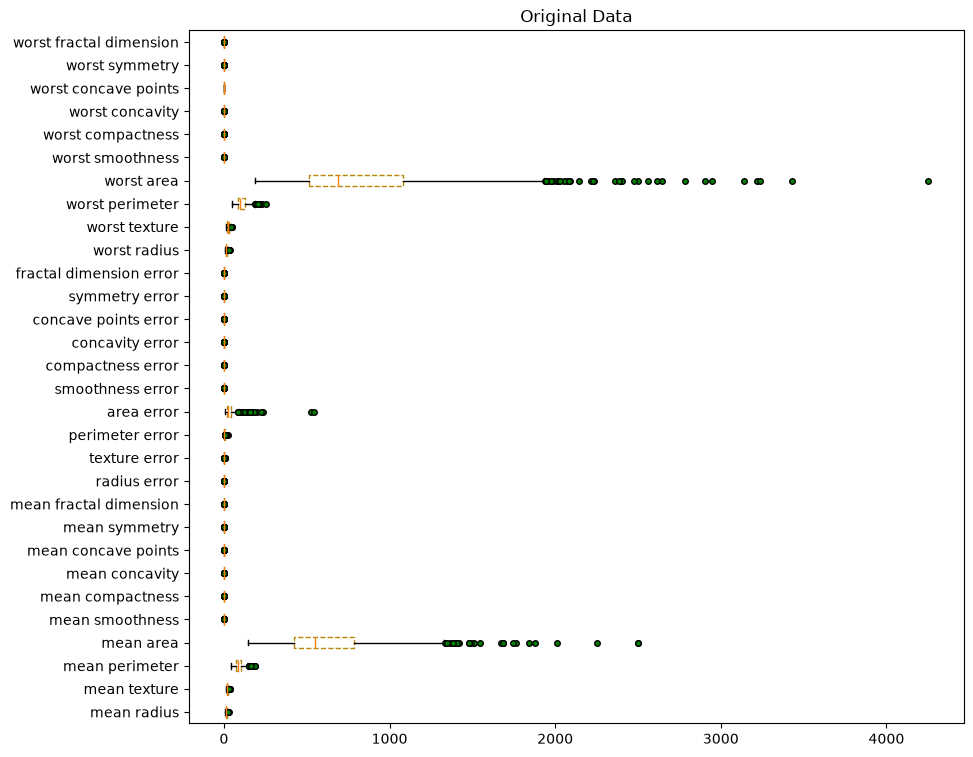

In [15]:
import matplotlib.pyplot as plt
import seaborn

# unstandardized
# ratings, categories are carried over from 1.
fig, ax = plt.subplots(figsize = (10,9))
boxprops = dict(linestyle = '--',linewidth = 1,color = 'darkgoldenrod') #E59016
flierprops = dict(marker='o', markerfacecolor = 'green', markersize = 4, linestyle = 'none')
ax.boxplot(data_, tick_labels= categories, boxprops = boxprops, flierprops = flierprops, orientation='horizontal')
plt.title('Original Data')
plt.show()

#### Discussion:
It can be observed that the distribution ranges vary significantly across data groups. Specifically, `worst_area` and `mean_area` have much larger values (skewed to the right), while other variables have smaller values (skewed to the left). Furthermore, the differences in variance are substantial, which may be unfavorable when performing principal component analysis (PCA). Therefore, it is necessary to first standardize these differences to scale the data into the same unit for fair comparison.

#### 2.2 Standardized Data:

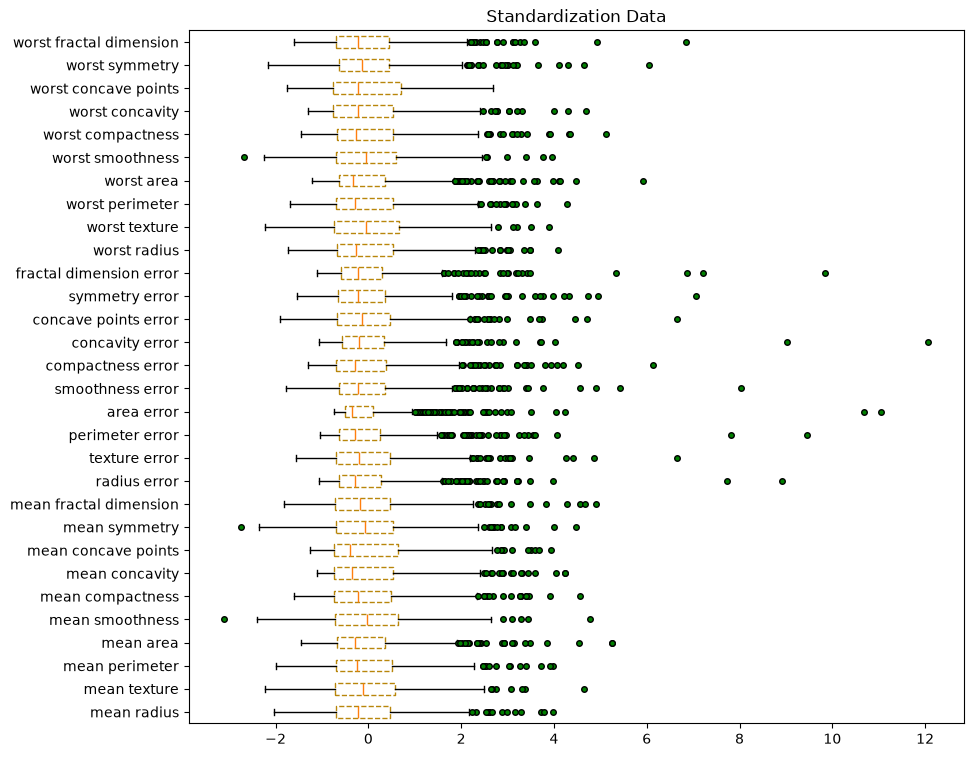

In [16]:
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler

# standardized
scaler = StandardScaler()
scaler.fit(data_)
S_data_ = scaler.transform(data_)

fig, ax = plt.subplots(figsize = (10,9))
boxprops = dict(linestyle = '--',linewidth = 1,color = 'darkgoldenrod') #E59016
flierprops = dict(marker='o', markerfacecolor = 'green', markersize = 4, linestyle = 'none')
ax.boxplot(S_data_, tick_labels = categories, boxprops = boxprops, flierprops = flierprops, orientation='horizontal')
plt.title('Standardization Data')
plt.show()

#### Discussion:

* **Scale Harmonization**: Following standardization (mean = 0, standard deviation = 1), all 30 features are now on a comparable scale. This eliminates the disproportionate dominance of high-magnitude features (such as `worst_area` and `mean_area`) and ensures that each feature contributes equally to the subsequent variance-based PCA.
* **Distribution & Outlier Analysis**: Post-scaling boxplots reveal that features like `concavity_error` retain noticeable outliers beyond the standard whiskers. These distributions demonstrate that while scaling normalizes the feature variance, non-normal skewness and outliers in specific features still warrant careful dimensionality reduction.

### 3. Scree Plot Showing the Magnitude of Eigenvalues
Perform principal component analysis, plot the distribution of eigenvalues from largest to smallest along with the scree plot, and refer to the layout in Figure 2.

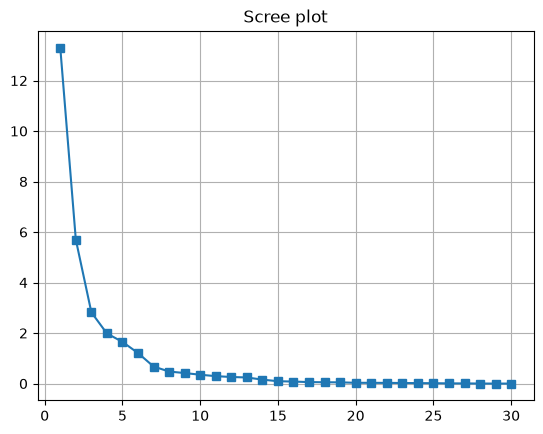

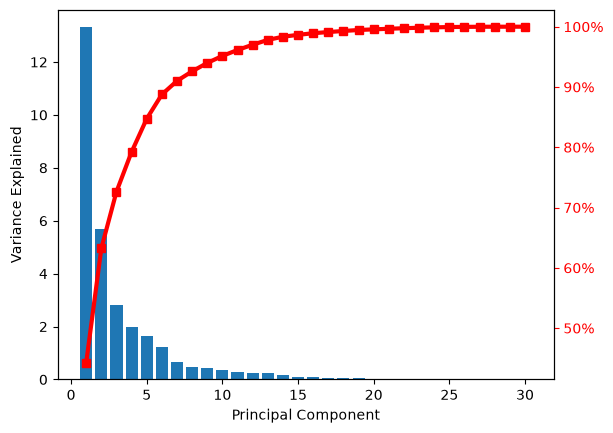

In [17]:
import numpy as np
from matplotlib.ticker import PercentFormatter
from matplotlib.pyplot import MultipleLocator
from sklearn.decomposition import PCA

Sx = np.cov(S_data_.T, bias = False) # standardized data # row as variables, column as observation of varaibles # unbias : n-1
X = np.c_[S_data_]
pca = PCA().fit(X)
eigvals = pca.explained_variance_
eigvecs = pca.components_.T

plt.figure() # initialize an empty figure
x = np.arange(1, 1+len(eigvals))
plt.plot(x, eigvals, marker='s')
plt.title('Scree plot')
plt.grid(True)
plt.show()

fig, ax = plt.subplots() # initialize an empty figure and axis
x = np.arange(1, 1+len(eigvals))
ax.bar(x, eigvals)
ax2 = ax.twinx() # add axes
ax2.plot(x, eigvals.cumsum()/eigvals.sum()*100, \
marker='s', color='red', lw=3) #.cumsum: cumulative sum of array
ax2.tick_params(axis='y', colors='red') # customize the tick styles # ticks_params(axis='x or y', width, color....)
ax2.yaxis.set_major_formatter(PercentFormatter()) # adjust y-axis ticks or formatting
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained')
plt.show()

#### Discussion:

* **Principal Component Analysis (PCA)** reduces data complexity while preserving information, aiming to represent the maximum components (variables) of the original data using the fewest variables. The new variables are linear combinations of the original variables, retaining the maximum variance among them.

* **The scree plot** displays eigenvalues as a downward-sloping curve, where an "elbow" point is often visually identified to suggest a suitable number of principal components. As an alternative approach, the **Kaiser criterion** recommends retaining principal components with eigenvalues greater than 1.

* **Data Correlation & Variance Concentration**: The original 30 features exhibit high multicollinearity. Because of this correlation, the variance is highly concentrated in the first few principal components, enabling us to effectively represent the original 30-dimensional data with a smaller subset of components.

* **Since there are 6 principal components with an eigenvalue > 1, it can be concluded that these first 6 principal components are sufficient to represent most of the variance in the original breast cancer dataset.**

### 4. The Impact of Standardization on PCA and Cluster Visualization
The tumors of breast cancer patients in the dataset can be divided into two groups: `Malignant` and `Benign`. Suppose we ignore this label for now. Without considering the data labels, when plotting a scatter plot using the first two principal components, **whether the data is standardized beforehand** has a critical impact on the analysis results:

#### 4.1 Unstandardized Data:

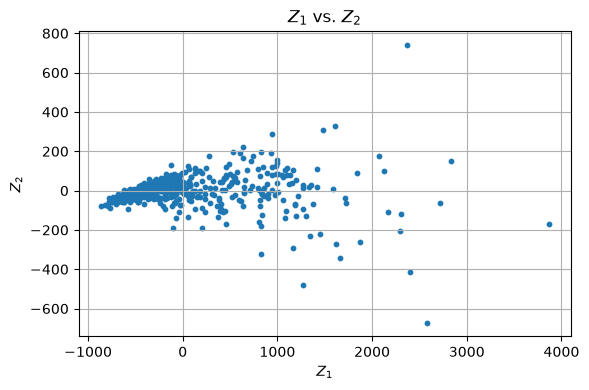

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# unstandardized
pca = PCA(n_components=2)
pca_ = pca.fit_transform(data_)

plt.figure(figsize = (6,4))
plt.scatter(pca_[:,0], pca_[:,1],s = 10)
plt.title("$Z_1$ vs. $Z_2$")
plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')
plt.grid(True)
plt.tight_layout()

#### Discussion:

* **Axis Distortion & Scale Dominance**: The scatter plot of the unstandardized data exhibits extreme coordinate ranges, with $Z_1$ spanning from roughly -1000 to 4000 and $Z_2$ reaching up to 800. This severe distortion is driven by unscaled high-magnitude features (such as `worst_area` and `mean_area`), which possess disproportionately large numerical variances.

* **Necessity of Standardization**: Because PCA relies entirely on variance maximization, failing to scale the data allows features with larger units to overshadow the rest. This unstandardized projection confirms that raw data features heavily bias the principal components, reinforcing the absolute necessity of feature scaling prior to meaningful dimensionality reduction and cluster analysis.

#### 4.2 Standardized Data:

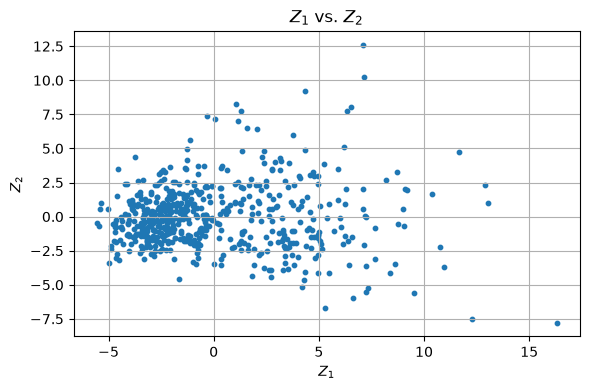

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# standardized
pca = PCA(n_components=2)
pca_ = pca.fit_transform(S_data_)

plt.figure(figsize = (6,4))
plt.scatter(pca_[:,0], pca_[:,1],s = 10)
plt.title("$Z_1$ vs. $Z_2$")
plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')
plt.grid(True)
plt.tight_layout()

#### Discussion:

**Unsupervised Distribution & Density**: Without looking at the labels (`Malignant` vs. `Benign`), the data points form a concentrated cluster primarily distributed on the left side of the $Z_1$ vs. $Z_2$ space, showing a significant improvement and more balanced coordinate spread compared to the unstandardized results.

### 5. PCA Scatter Plot Colored by Tumor Classes
Color each data point in the scatter plot based on its respective label.

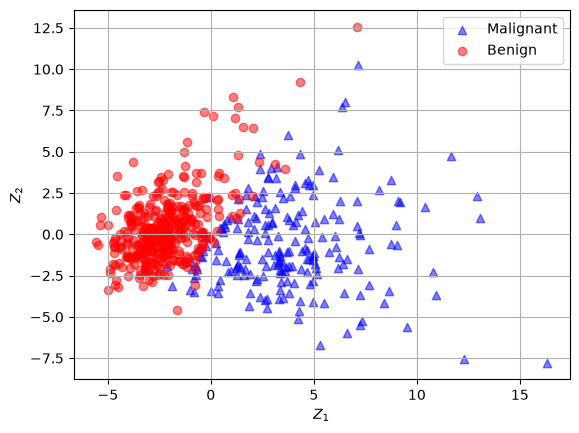

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scaler = StandardScaler()
scaler.fit(data_)
S_data_ = scaler.transform(data_)
pca = PCA(n_components=2)
pca_ = pca.fit_transform(S_data_)

breast_cancer_labels = df.target.reshape((569,1))
cancer_labels = breast_cancer_labels[:,0]
targets = [0,1]
labels = ['Malignant','Benign']
colors = ['blue','red']
markers = ['^','o']

for target, color, marker in zip(targets,colors,markers):
    plt.scatter(pca_[cancer_labels == target,0], pca_[cancer_labels == target,1], label = labels[target],color = color, alpha = 0.5, marker = marker)
plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')
plt.grid(True)
plt.legend(loc="upper right")
plt.show()

#### Discussion:

* **Supervised Class Separation**: After coloring the data points based on their true tumor labels (`Benign` vs. `Malignant`), it is evident that the data forms two distinct clusters (`Benign` and `Malignant`) with meaningful class-discriminatory patterns along the principal components.

* **Significance of Standardization**: This highlights the necessity of data standardization: unstandardized data yields a distorted and scale-biased distribution after PCA, whereas standardized data successfully reveals the underlying two-class structure of the breast cancer dataset.

### 6. Three-Dimensional Principal Component Analysis
Although Kaiser's criterion (eigenvalues $> 1$) indicates that 6 principal components are retained, visualizing all 6 dimensions simultaneously is impractical. Therefore, we examine the first three principal components. If three principal components are used, 3D scatter plots as shown in Figure 3 and Figure 4 can be generated. Observe whether Figures 3 and 4 provide better cluster separation capability compared to Figure 2. Try rotating the 3D plot's perspective to achieve the best viewing angle for discrimination.

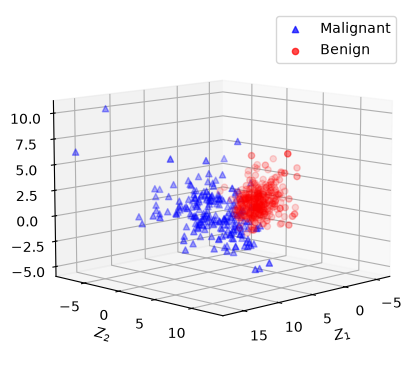

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d.axes3d import Axes3D

scaler = StandardScaler()
scaler.fit(data_)
S_data_ = scaler.transform(data_)
pca = PCA(n_components=3)
pca_ = pca.fit_transform(S_data_)

breast_cancer_labels = df.target.reshape((569,1))
cancer_labels = breast_cancer_labels[:,0]
targets = [0,1]
labels = ['Malignant','Benign']
colors = ['blue','red']
markers = ['^','o']

fig = plt.figure()
ax1 = fig.add_subplot(projection='3d')
for target, color, marker in zip(targets,colors,markers):
    ax1.scatter(pca_[cancer_labels == target,0], pca_[cancer_labels == target,1],pca_[cancer_labels == target,2], label = labels[target],color = color, alpha = 0.7,marker = marker)
ax1.view_init(10, 45)
plt.xlabel('$Z_1$')
plt.ylabel('$Z_2$')
plt.grid(True)
plt.legend(loc="upper right")
plt.show()

#### Discussion:

* The viewing angles of the 3D plot consist of two components: **elevation** and **azimuth** (`view_init(10, 45)`). By adjusting these angles, the data points are clearly separated into two distinct groups (`Benign` and `Malignant`) with minimal overlap.

* Based on the cumulative explained variance, the first two principal components capture about 63.2% of the total variance, and adding the third raises this to about 72.6%. Kaiser's criterion (eigenvalue > 1) would retain 6 components, but the first three already capture most of the variance and are the most that can be plotted directly, so the 3D visualization effectively highlights the cluster structure of the breast cancer dataset.

### 7. 
$Z_1$ and $Z_2$ are new variables formed by combining the original variables. Can we determine which original variables are more important and which are less important from the loading coefficients of $Z_1$ and $Z_2$?

In [22]:
# the first two eigenvectors of the covariance matrix
z = pca.components_[:3,:] 
print(z) 

[[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]
 [-0.00853124  0.0645499  -0.00931422  0.02869953 -0.1042919  -0.07409157
   0.00273384 -0.02556354 -0.04023994 -0.02257409  0.26848139  0.37463367
   0.26664537  0.21600653  0.30883898  0.15477972  0.17646374  0.22465757
   0.28858429  0.21150376 -0.04750699

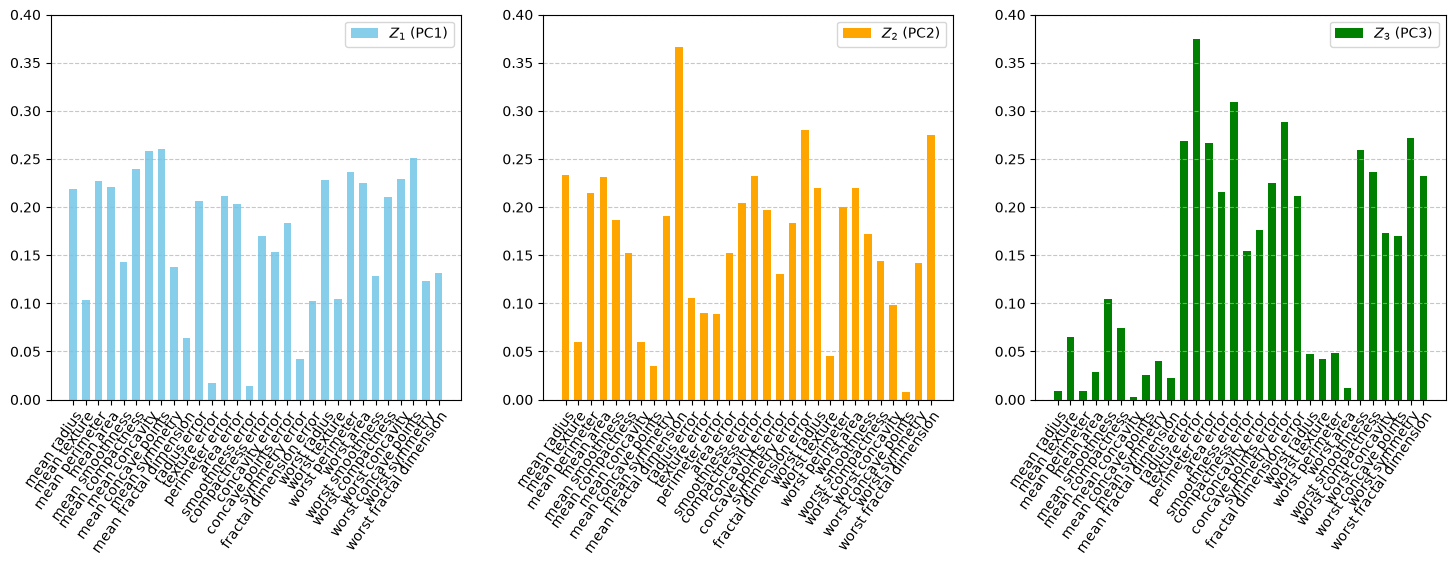

In [23]:
bar_width = 0.6
z = np.abs(pca.components_[:3,:])
x = np.arange(z.shape[1])
categories = df.feature_names

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), sharex=True)

# z1
axes[0].bar(x, z[0, :], width=bar_width, color='skyblue', label='$Z_1$ (PC1)')
axes[0].legend(loc='upper right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# z2
axes[1].bar(x, z[1, :], width=bar_width, color='orange', label='$Z_2$ (PC2)')
axes[1].legend(loc='upper right')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# z3
axes[2].bar(x, z[2, :], width=bar_width, color='green', label='$Z_3$ (PC3)')
axes[2].legend(loc='upper right')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

for ax in axes:
    ax.set_ylim(0, 0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=55, ha='right', rotation_mode='anchor')

#fig, ax = plt.subplots(figsize = (16,8))
#ax.bar(x, z[0,:], width=bar_width,label = "Z1")
#ax.bar(x + bar_width, z[1,:], width=bar_width,label = "Z2")
#ax.bar(x + 2*bar_width, z[2,:], width=bar_width,label = "Z3")
#ax.set_xticks(x+2*bar_width/3)
#ax.set_xticklabels(categories,rotation = 55)

plt.legend()
plt.show()

#### Conclusion:
* **$Z_1$** is primarily composed of `mean concave points`, `mean concavity`, and `worst concave points`.

* **$Z_2$** is primarily composed of `mean fractal dimension`, `fractal dimension error`, and `worst fractal dimension`.

* **$Z_3$** is primarily composed of `texture error`, `smoothness error`, and `symmetry error`.

### 8.
Compared with the correlation coefficient plot of the original variables, does it reveal the same information?

<Axes: >

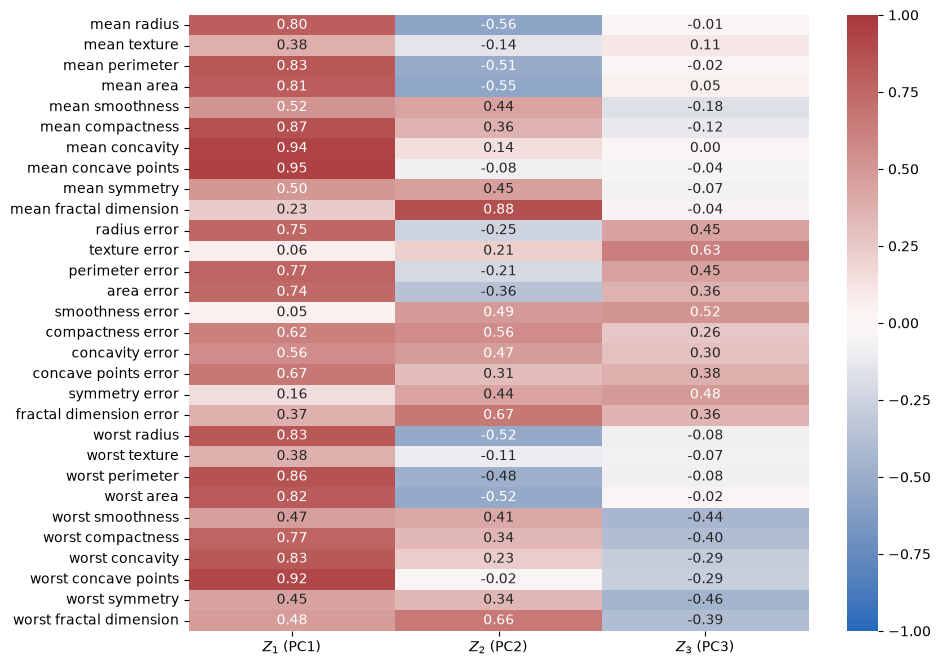

In [24]:
pca = PCA(n_components=3)
pca.fit(S_data_)
z = (pca.components_.T * np.sqrt(pca.explained_variance_))[:, :3]

L = pd.DataFrame(z,index = categories, columns = ['$Z_1$ (PC1)', '$Z_2$ (PC2)', '$Z_3$ (PC3)'])
R = data_.corr()

plt.figure(figsize = (10,8))
seaborn.heatmap(L, annot = True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1,
            center=0)

#### Conclusion:

* **For $Z_1$**: The loadings indicate that `mean concave points` (0.95), `mean concavity` (0.94), `worst concave points` (0.92), `mean compactness` (0.87), and perimeter/radius/area-related variables contribute strongly to PC1. In contrast, variables such as `texture error` and `smoothness error` have loadings close to zero and therefore contribute relatively little to PC1.

* **For $Z_2$**: $Z_2$ is dominated by fractal-dimension-related variables, especially `mean fractal dimension` (0.88) and `fractal dimension error` (0.67), `worst fractal dimension` (0.66). Meanwhile, variables such as `mean radius` (-0.56), `mean area` (-0.55), `worst radius` (-0.52), and `worst area` (-0.52) also have relatively large absolute coefficients, indicating substantial but negative contributions to PC2.

* **For $Z_3$**: $Z_3$ is dominated by error and texture-related variables, especially `texture error` (0.63) and `smoothness error` (0.52) (along with `symmetry error` (0.48), `radius error` (0.45), and `perimeter error` (0.45)). Meanwhile, variables such as `worst symmetry` (-0.46), `worst smoothness` (-0.44), and `worst fractal dimension` (-0.39) also have relatively large absolute loadings, indicating substantial but negative contributions to $Z_3$.

* **Comparison with the Correlation Matrix**:
The loadings and the original correlation matrix reveal similar patterns but provide different information. The correlation matrix shows strong relationships among groups of original variables, such as radius, perimeter, and area measurements. These groups also tend to have relatively large loadings in the principal components. However, the correlation matrix describes relationships between pairs of original variables, whereas the loadings describe the contribution of each variable to a principal component.

* **Overall**:
Therefore, the correlation matrix can help explain why certain variables tend to contribute together to a principal component, but the absolute values of the loadings are more directly useful for determining which variables are important for $Z_1$, $Z_2$, and $Z_3$.

